In [1]:
import pandas as pd   # for loading and working with tabular data
import numpy as np    # for numerical operations
import matplotlib.pyplot as plt  # for plotting graphs

# split data into training and validation sets
from sklearn.model_selection import train_test_split

# evaluation metrics
from sklearn.metrics import (
    classification_report,      # precision, recall, f1-score
    confusion_matrix,           # confusion matrix counts
    roc_auc_score,              # ROC AUC metric
    average_precision_score,    # PR AUC metric
    precision_recall_curve,     # values for PR curve
    roc_curve                   # values for ROC curve
)

# CatBoost model
from catboost import CatBoostClassifier

In [2]:
# Load the training transaction data
train_trans = pd.read_csv("../data/raw/train_transaction.csv")

# Load the training identity data
train_id = pd.read_csv("../data/raw/train_identity.csv")

# Merge both tables on TransactionID
# Keep every transaction row, even if identity data is missing
df = train_trans.merge(train_id, on="TransactionID", how="left")

# Show shape and first few rows
print(df.shape)
df.head()

(590540, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [3]:
# Target column: what we want to predict
y = df["isFraud"]

# Drop target and ID column from features
drop_cols = ["isFraud", "TransactionID"]

# X contains the feature columns
X = df.drop(columns=drop_cols)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (590540, 432)
y shape: (590540,)


In [4]:
# Compute fraction of missing values per column
missing_pct = X.isnull().mean()

# Find columns with more than 90% missing values
# These columns are mostly empty, so we remove them
high_missing_cols = missing_pct[missing_pct > 0.90].index.tolist()

# Print how many columns will be removed
print("Dropping", len(high_missing_cols), "columns with >90% missing values")

# Drop those columns
X = X.drop(columns=high_missing_cols)

# Check the new shape
print("New X shape:", X.shape)

Dropping 12 columns with >90% missing values
New X shape: (590540, 420)


In [5]:
# Get categorical/text columns
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

# Get numeric columns just for reference
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

# Print counts
print("Categorical features:", len(categorical_features))
print("Numeric features:", len(numeric_features))

Categorical features: 29
Numeric features: 391


C:\Users\hariv\AppData\Local\Temp\ipykernel_14372\954171711.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


In [6]:
# Split into training and validation sets
# stratify=y keeps the fraud percentage similar in both sets
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Print shapes and fraud rates
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("Fraud rate train:", y_train.mean())
print("Fraud rate val:", y_val.mean())

X_train: (472432, 420)
X_val: (118108, 420)
Fraud rate train: 0.03498916246147594
Fraud rate val: 0.0349933958749619


In [7]:
# Make copies so we do not modify the original train/validation splits
X_train_cb = X_train.copy()
X_val_cb = X_val.copy()

# Fill missing values in categorical columns with a placeholder string
# CatBoost can handle categories, but missing strings should be made explicit
for col in categorical_features:
    X_train_cb[col] = X_train_cb[col].fillna("MISSING").astype(str)
    X_val_cb[col] = X_val_cb[col].fillna("MISSING").astype(str)

# Quick check
print("Prepared categorical columns for CatBoost.")

Prepared categorical columns for CatBoost.


In [8]:
# For numeric columns, fill missing values with the median from the training data
# This keeps things simple and avoids leakage from validation into training
for col in numeric_features:
    median_value = X_train_cb[col].median()
    X_train_cb[col] = X_train_cb[col].fillna(median_value)
    X_val_cb[col] = X_val_cb[col].fillna(median_value)

# Quick check
print("Filled missing numeric values.")

Filled missing numeric values.


In [9]:
# CatBoost wants the positions (indices) of categorical columns
cat_feature_indices = [X_train_cb.columns.get_loc(col) for col in categorical_features]

# Print a small sample and total count
print("Number of categorical feature indices:", len(cat_feature_indices))
print("First 10 categorical indices:", cat_feature_indices[:10])

Number of categorical feature indices: 29
First 10 categorical indices: [2, 6, 8, 12, 13, 42, 43, 44, 45, 46]


In [10]:
# Count number of non-fraud and fraud examples in the training set
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()

# Compute class weight for fraud
fraud_weight = neg_count / pos_count

print("Negative count:", neg_count)
print("Positive count:", pos_count)
print("Fraud class weight:", fraud_weight)

Negative count: 455902
Positive count: 16530
Fraud class weight: 27.580278281911674


In [11]:
# Create the CatBoost classifier
# verbose=100 prints training progress every 100 iterations
cat_model = CatBoostClassifier(
    iterations=300,          # number of boosting rounds / trees
    depth=6,                 # tree depth
    learning_rate=0.1,       # step size
    eval_metric="AUC",       # evaluation metric during training
    loss_function="Logloss", # binary classification loss
    random_seed=42,          # reproducibility
    class_weights=[1, fraud_weight],  # handle class imbalance
    verbose=100
)

In [12]:
# Fit the CatBoost model
# cat_features tells CatBoost which columns are categorical
cat_model.fit(
    X_train_cb,
    y_train,
    cat_features=cat_feature_indices
)

0:	total: 2.06s	remaining: 10m 17s
100:	total: 2m 41s	remaining: 5m 17s
200:	total: 5m 36s	remaining: 2m 45s
299:	total: 8m 8s	remaining: 0us


CatBoostClassifier(class_weights=[1, np.float64(27.580278281911674)], depth=6, eval_metric='AUC', iterations=300, learning_rate=0.1, loss_function='Logloss', random_seed=42, verbose=100)

In [13]:
# Predict fraud class labels
y_pred_cat = cat_model.predict(X_val_cb)

# Predict fraud probabilities
y_proba_cat = cat_model.predict_proba(X_val_cb)[:, 1]

In [14]:
# Print classification report
print("CatBoost Classification Report:")
print(classification_report(y_val, y_pred_cat))

# Print key metrics
print("CatBoost ROC AUC:", roc_auc_score(y_val, y_proba_cat))
print("CatBoost PR AUC:", average_precision_score(y_val, y_proba_cat))

CatBoost Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.90      0.95    113975
           1       0.24      0.82      0.37      4133

    accuracy                           0.90    118108
   macro avg       0.62      0.86      0.66    118108
weighted avg       0.97      0.90      0.93    118108

CatBoost ROC AUC: 0.9364502776644543
CatBoost PR AUC: 0.643635422007415


In [15]:
# Compute confusion matrix
cm_cat = confusion_matrix(y_val, y_pred_cat)

print("CatBoost Confusion Matrix:")
print(cm_cat)

CatBoost Confusion Matrix:
[[103089  10886]
 [   738   3395]]


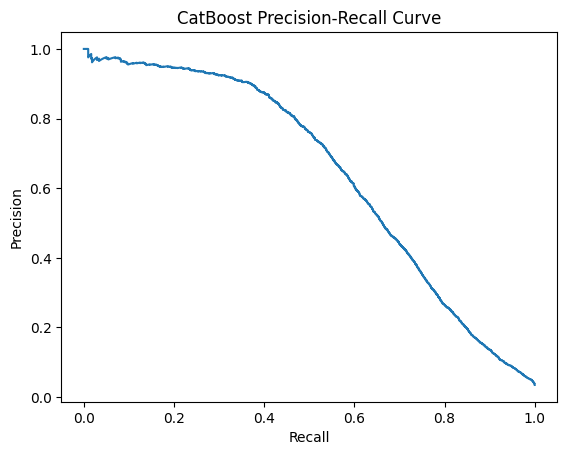

In [16]:
# Compute PR curve values
precision_cat, recall_cat, thresholds_cat = precision_recall_curve(y_val, y_proba_cat)

# Plot PR curve
plt.plot(recall_cat, precision_cat)

# Labels and title
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("CatBoost Precision-Recall Curve")

# Show plot
plt.show()

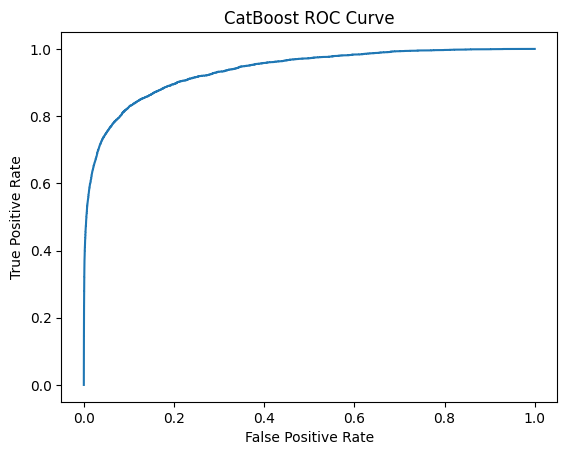

In [17]:
# Compute ROC curve values
fpr_cat, tpr_cat, roc_thresholds_cat = roc_curve(y_val, y_proba_cat)

# Plot ROC curve
plt.plot(fpr_cat, tpr_cat)

# Labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CatBoost ROC Curve")

# Show plot
plt.show()

In [18]:
# Get feature importance scores from the trained CatBoost model
feature_importance_cat = pd.Series(
    cat_model.feature_importances_,
    index=X_train_cb.columns
).sort_values(ascending=False)

# Show top 20 most important features
print(feature_importance_cat.head(20))

card2             6.210540
card1             5.155116
C13               4.800217
addr1             3.373709
D1                3.309858
C14               2.922574
TransactionAmt    2.912535
C2                2.660200
C1                2.638820
M5                2.538611
card5             2.514177
dist1             2.468281
D15               2.339057
TransactionDT     2.172888
D2                2.162731
card6             1.926875
C5                1.916041
M6                1.792511
M4                1.638835
C11               1.535847
dtype: float64


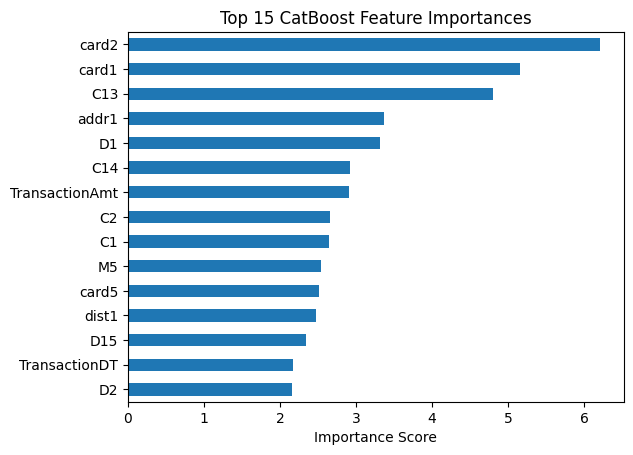

In [19]:
# Plot the top 15 most important features
feature_importance_cat.head(15).sort_values().plot(kind="barh")

# Add labels and title
plt.xlabel("Importance Score")
plt.title("Top 15 CatBoost Feature Importances")

# Show plot
plt.show()

In [20]:
# Count predicted frauds and actual frauds
print("Predicted frauds by CatBoost:", y_pred_cat.sum())
print("Actual frauds in validation:", y_val.sum())

# Average predicted fraud probability
print("Average predicted fraud probability:", y_proba_cat.mean())

Predicted frauds by CatBoost: 14281
Actual frauds in validation: 4133
Average predicted fraud probability: 0.2312112529955665
